# Entrenamiento EfficientNetB3 - PlantVillage
**Arquitectura:** EfficientNetB3 con pesos preentrenados en PlantVillage (AP_pesos.h5)

**Dataset:** PlantVillage (Kaggle) - carpetas por clase

**Clases:** 38 enfermedades de plantas

> **Nota:** Se usan pesos ya fine-tuneados en PlantVillage, por lo que NO se necesita conexión a internet para descargar pesos de ImageNet.

## 1. Imports

In [21]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import json
import time
from itertools import cycle

import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    roc_curve, auc, confusion_matrix, classification_report
)

print('TensorFlow version:', tf.__version__)
print('GPU disponible:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 2. Rutas de archivos

Ajusta las rutas según los nombres de tus datasets en Kaggle.

In [22]:
# ── AJUSTA ESTAS RUTAS ──────────────────────────────────────────────────────
# Ruta al dataset de imágenes (carpeta color con subcarpetas por clase)
DATA_DIR = '/kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color'

# Ruta al archivo de pesos preentrenados
WEIGHTS_PATH = '/kaggle/input/datasets/yennybelhancco/pesos1/AP_pesos.h5'
# ─────────────────────────────────────────────────────────────────────────────

# Verificar dataset
if os.path.exists(DATA_DIR):
    categories = sorted(os.listdir(DATA_DIR))
    print(f'Dataset encontrado: {DATA_DIR}')
    print(f'Total de clases: {len(categories)}')
    for i, cat in enumerate(categories):
        count = len(glob.glob(os.path.join(DATA_DIR, cat, '*.[jJ][pP][gG]')))
        print(f'  {i+1:2d}. {cat:55s} → {count} imágenes')
else:
    print(f'ERROR: No se encontró {DATA_DIR}')
    print('Datasets disponibles en /kaggle/input/:')
    for d in os.listdir('/kaggle/input'):
        print(f'  /kaggle/input/{d}')

print()
if os.path.exists(WEIGHTS_PATH):
    size_mb = os.path.getsize(WEIGHTS_PATH) / 1e6
    print(f'Pesos encontrados: {WEIGHTS_PATH} ({size_mb:.1f} MB)')
else:
    print(f'ERROR: No se encontraron los pesos en {WEIGHTS_PATH}')

Dataset encontrado: /kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color
Total de clases: 38
   1. Apple___Apple_scab                                      → 630 imágenes
   2. Apple___Black_rot                                       → 621 imágenes
   3. Apple___Cedar_apple_rust                                → 275 imágenes
   4. Apple___healthy                                         → 1645 imágenes
   5. Blueberry___healthy                                     → 1502 imágenes
   6. Cherry_(including_sour)___Powdery_mildew                → 1052 imágenes
   7. Cherry_(including_sour)___healthy                       → 854 imágenes
   8. Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot      → 513 imágenes
   9. Corn_(maize)___Common_rust_                             → 1192 imágenes
  10. Corn_(maize)___Northern_Leaf_Blight                     → 985 imágenes
  11. Corn_(maize)___healthy                                  → 1162 imágenes
  12. Grape___Black_rot                    

## 3. Parámetros

In [23]:
# EfficientNetB3 usa 300x300
BATCH_SIZE    = 32
IMG_SIZE      = 300     # ← B3 requiere 300, NO 224 como B0
EPOCHS        = 20
LEARNING_RATE = 0.0001  # LR bajo porque los pesos ya están bien ajustados

num_classes = len(categories)
print(f'Número de clases: {num_classes}')
print(f'Tamaño de imagen: {IMG_SIZE}x{IMG_SIZE}')
print(f'Batch size: {BATCH_SIZE}')
print(f'Épocas máximas: {EPOCHS}')
print(f'Learning rate: {LEARNING_RATE}')

Número de clases: 38
Tamaño de imagen: 300x300
Batch size: 32
Épocas máximas: 20
Learning rate: 0.0001


In [24]:
import shutil
import os

# Crear un directorio de trabajo con todas las clases
WORK_DIR = '/kaggle/working/dataset_completo'

# Copiar el dataset original
if not os.path.exists(WORK_DIR):
    print('Copiando dataset completo...')
    shutil.copytree(DATA_DIR, WORK_DIR)
    print('Dataset copiado.')

# Copiar Background al directorio de trabajo
BACKGROUND_SRC = '/kaggle/input/datasets/yennybelhancco/background-withou-leaves/Background_without_leaves'
BACKGROUND_DST = os.path.join(WORK_DIR, 'Background_without_leaves')

if not os.path.exists(BACKGROUND_DST):
    shutil.copytree(BACKGROUND_SRC, BACKGROUND_DST)
    print(f'Background copiado: {len(os.listdir(BACKGROUND_DST))} imágenes')

# Actualizar DATA_DIR
DATA_DIR = WORK_DIR
categories = sorted(os.listdir(DATA_DIR))
num_classes = len(categories)
print(f'Total clases: {num_classes}')
print(f'Clases: {categories}')

Copiando dataset completo...
Dataset copiado.
Background copiado: 1143 imágenes
Total clases: 39
Clases: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Background_without_leaves', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___L

## 4. Generadores de datos

In [25]:
# Generador de entrenamiento con aumentación
train_datagen = ImageDataGenerator(
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.2,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

# Generador de validación sin aumentación
val_datagen = ImageDataGenerator(
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    subset='training',
    class_mode='categorical',
    shuffle=True,
    seed=42
)

val_gen = val_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    subset='validation',
    class_mode='categorical',
    shuffle=False,
    seed=42
)

class_names = list(train_gen.class_indices.keys())
print(f'Imágenes de entrenamiento: {train_gen.samples}')
print(f'Imágenes de validación:    {val_gen.samples}')
print(f'Clases detectadas:         {len(class_names)}')

Found 44371 images belonging to 39 classes.
Found 11077 images belonging to 39 classes.
Imágenes de entrenamiento: 44371
Imágenes de validación:    11077
Clases detectadas:         39


## 5. Cargar modelo con pesos preentrenados

En lugar de descargar EfficientNetB0 desde internet, cargamos directamente  que ya contiene EfficientNetB3 fine-tuneado en PlantVillage.

In [26]:
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization

print('Descargando EfficientNetB3 con pesos ImageNet...')

base_model = EfficientNetB3(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False  # Congelar base

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    BatchNormalization(),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('Modelo listo.')
model.summary()

Descargando EfficientNetB3 con pesos ImageNet...
Modelo listo.


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb3 (Functional)     │ (None, 10, 10, 1536)   │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 39)             │        10,023 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,193,174 (42.70 MB)

 Trainable params: 406,567 (1.55 MB)

 Non-trainable params: 10,786,607 (41.15 MB)

## 6. Preparar para fine-tuning

Descongelamos las últimas capas de EfficientNetB3 para continuar el entrenamiento con el dataset.

In [27]:
# La base EfficientNetB3 es la primera capa del modelo
base_model = model.layers[0]

# Congelar todas las capas de la base primero
base_model.trainable = True

# Descongelar solo las últimas 30 capas para fine-tuning
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompilar con learning rate bajo (importante después de descongelar capas)
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Contar parámetros
trainable = sum([tf.size(w).numpy() for w in model.trainable_weights])
non_trainable = sum([tf.size(w).numpy() for w in model.non_trainable_weights])
print(f'Parámetros entrenables:    {trainable:,}')
print(f'Parámetros no entrenables: {non_trainable:,}')

Parámetros entrenables:    3,960,737
Parámetros no entrenables: 7,232,437


## 7. Callbacks

In [28]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=3,
        verbose=1,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        'best_efficientnetb3.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

print('Callbacks configurados:')
print('  - EarlyStopping (patience=3)')
print('  - ModelCheckpoint → best_efficientnetb3.h5')
print('  - ReduceLROnPlateau (factor=0.5, patience=2)')

Callbacks configurados:
  - EarlyStopping (patience=3)
  - ModelCheckpoint → best_efficientnetb3.h5
  - ReduceLROnPlateau (factor=0.5, patience=2)


## 8. Entrenamiento (fine-tuning)

In [29]:
print('='*60)
print('INICIANDO FINE-TUNING - EfficientNetB3')
print('='*60)

start_time = time.time()

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

elapsed = time.time() - start_time
print(f'Tiempo total de entrenamiento: {elapsed/60:.1f} minutos')

INICIANDO FINE-TUNING - EfficientNetB3
Epoch 1/20
 609/1387 ━━━━━━━━━━━━━━━━━━━━ 9:06 702ms/step - accuracy: 0.5910 - loss: 1.6401

2026-05-24 17:18:13.239715: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-24 17:18:13.387432: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-24 17:18:13.776460: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-24 17:18:13.924482: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-24 17:18:14.740130: E external/local_xla/xla/stream_

1387/1387 ━━━━━━━━━━━━━━━━━━━━ 0s 725ms/step - accuracy: 0.7264 - loss: 1.0700

2026-05-24 17:28:42.982312: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-24 17:28:43.120943: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-24 17:28:43.440911: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-24 17:28:43.588277: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-24 17:28:43.734682: E external/local_xla/xla/stream_


Epoch 1: val_accuracy improved from -inf to 0.96705, saving model to best_efficientnetb3.h5


...

1387/1387 ━━━━━━━━━━━━━━━━━━━━ 993s 716ms/step - accuracy: 0.9947 - loss: 0.0140 - val_accuracy: 0.9940 - val_loss: 0.0198 - learning_rate: 5.0000e-05
Epoch 17/20
1387/1387 ━━━━━━━━━━━━━━━━━━━━ 0s 673ms/step - accuracy: 0.9966 - loss: 0.0099
Epoch 17: val_accuracy improved from 0.99395 to 0.99413, saving model to best_efficientnetb3.h5


1387/1387 ━━━━━━━━━━━━━━━━━━━━ 981s 707ms/step - accuracy: 0.9966 - loss: 0.0099 - val_accuracy: 0.9941 - val_loss: 0.0215 - learning_rate: 5.0000e-05
Epoch 18/20
1387/1387 ━━━━━━━━━━━━━━━━━━━━ 0s 705ms/step - accuracy: 0.9967 - loss: 0.0096
Epoch 18: val_accuracy improved from 0.99413 to 0.99458, saving model to best_efficientnetb3.h5



Epoch 18: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
1387/1387 ━━━━━━━━━━━━━━━━━━━━ 1027s 740ms/step - accuracy: 0.9967 - loss: 0.0096 - val_accuracy: 0.9946 - val_loss: 0.0205 - learning_rate: 5.0000e-05
Epoch 19/20
1387/1387 ━━━━━━━━━━━━━━━━━━━━ 0s 707ms/step - accuracy: 0.9970 - loss: 0.0084
Epoch 19: val_accuracy improved from 0.99458 to 0.99549, saving model to best_efficientnetb3.h5


1387/1387 ━━━━━━━━━━━━━━━━━━━━ 1029s 742ms/step - accuracy: 0.9970 - loss: 0.0084 - val_accuracy: 0.9955 - val_loss: 0.0180 - learning_rate: 2.5000e-05
Epoch 20/20
1387/1387 ━━━━━━━━━━━━━━━━━━━━ 0s 714ms/step - accuracy: 0.9977 - loss: 0.0073
Epoch 20: val_accuracy improved from 0.99549 to 0.99585, saving model to best_efficientnetb3.h5


1387/1387 ━━━━━━━━━━━━━━━━━━━━ 1039s 749ms/step - accuracy: 0.9977 - loss: 0.0073 - val_accuracy: 0.9958 - val_loss: 0.0166 - learning_rate: 2.5000e-05
Restoring model weights from the end of the best epoch: 20.
Tiempo total de entrenamiento: 339.1 minutos


## 9. Evaluación

In [32]:
val_loss, val_acc = model.evaluate(val_gen, verbose=1)
print(f'Validation Loss:     {val_loss:.4f}')
print(f'Validation Accuracy: {val_acc:.4f} ({val_acc*100:.2f}%)')

347/347 ━━━━━━━━━━━━━━━━━━━━ 49s 141ms/step - accuracy: 0.9955 - loss: 0.0206
Validation Loss:     0.0166
Validation Accuracy: 0.9958 (99.58%)


## 10. Curvas de entrenamiento

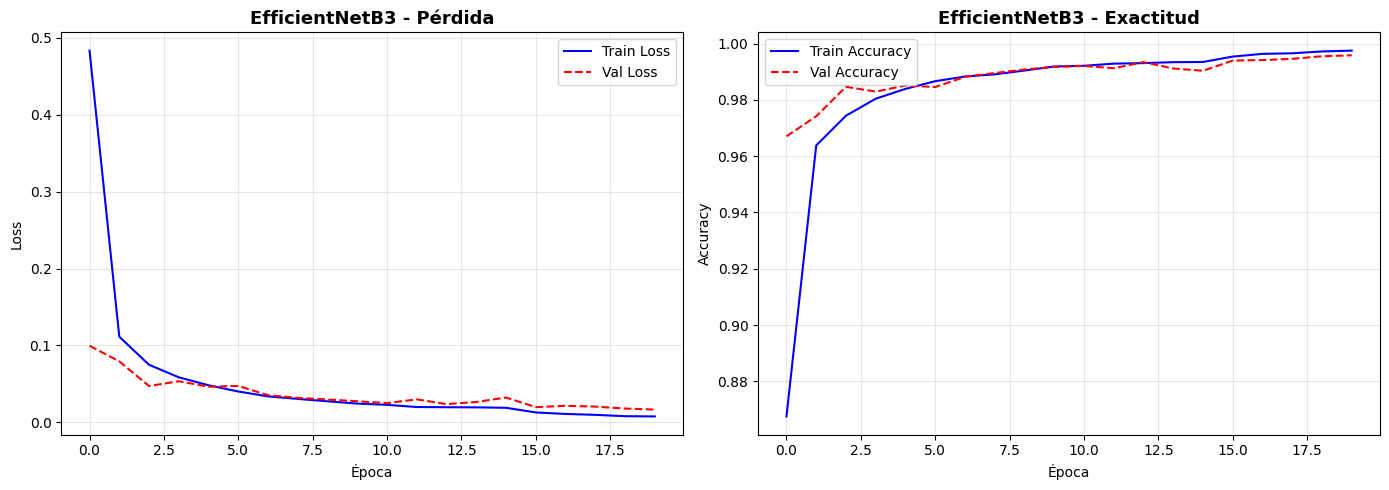

In [33]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'],     label='Train Loss',  color='blue')
plt.plot(history.history['val_loss'], label='Val Loss',    color='red', linestyle='--')
plt.title('EfficientNetB3 - Pérdida', fontsize=13, fontweight='bold')
plt.xlabel('Época'); plt.ylabel('Loss')
plt.legend(); plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'],     label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Val Accuracy',   color='red', linestyle='--')
plt.title('EfficientNetB3 - Exactitud', fontsize=13, fontweight='bold')
plt.xlabel('Época'); plt.ylabel('Accuracy')
plt.legend(); plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('efficientnetb3_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Predicciones y métricas

In [34]:
print('Generando predicciones...')
val_gen.reset()
y_pred_proba = model.predict(val_gen, verbose=1)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = val_gen.classes

print(f'Muestras evaluadas: {len(y_pred)}')
print(f'Accuracy manual:    {np.mean(y_true == y_pred)*100:.2f}%')

Generando predicciones...
347/347 ━━━━━━━━━━━━━━━━━━━━ 70s 170ms/step
Muestras evaluadas: 11077
Accuracy manual:    99.58%


## 12. Matriz de confusión

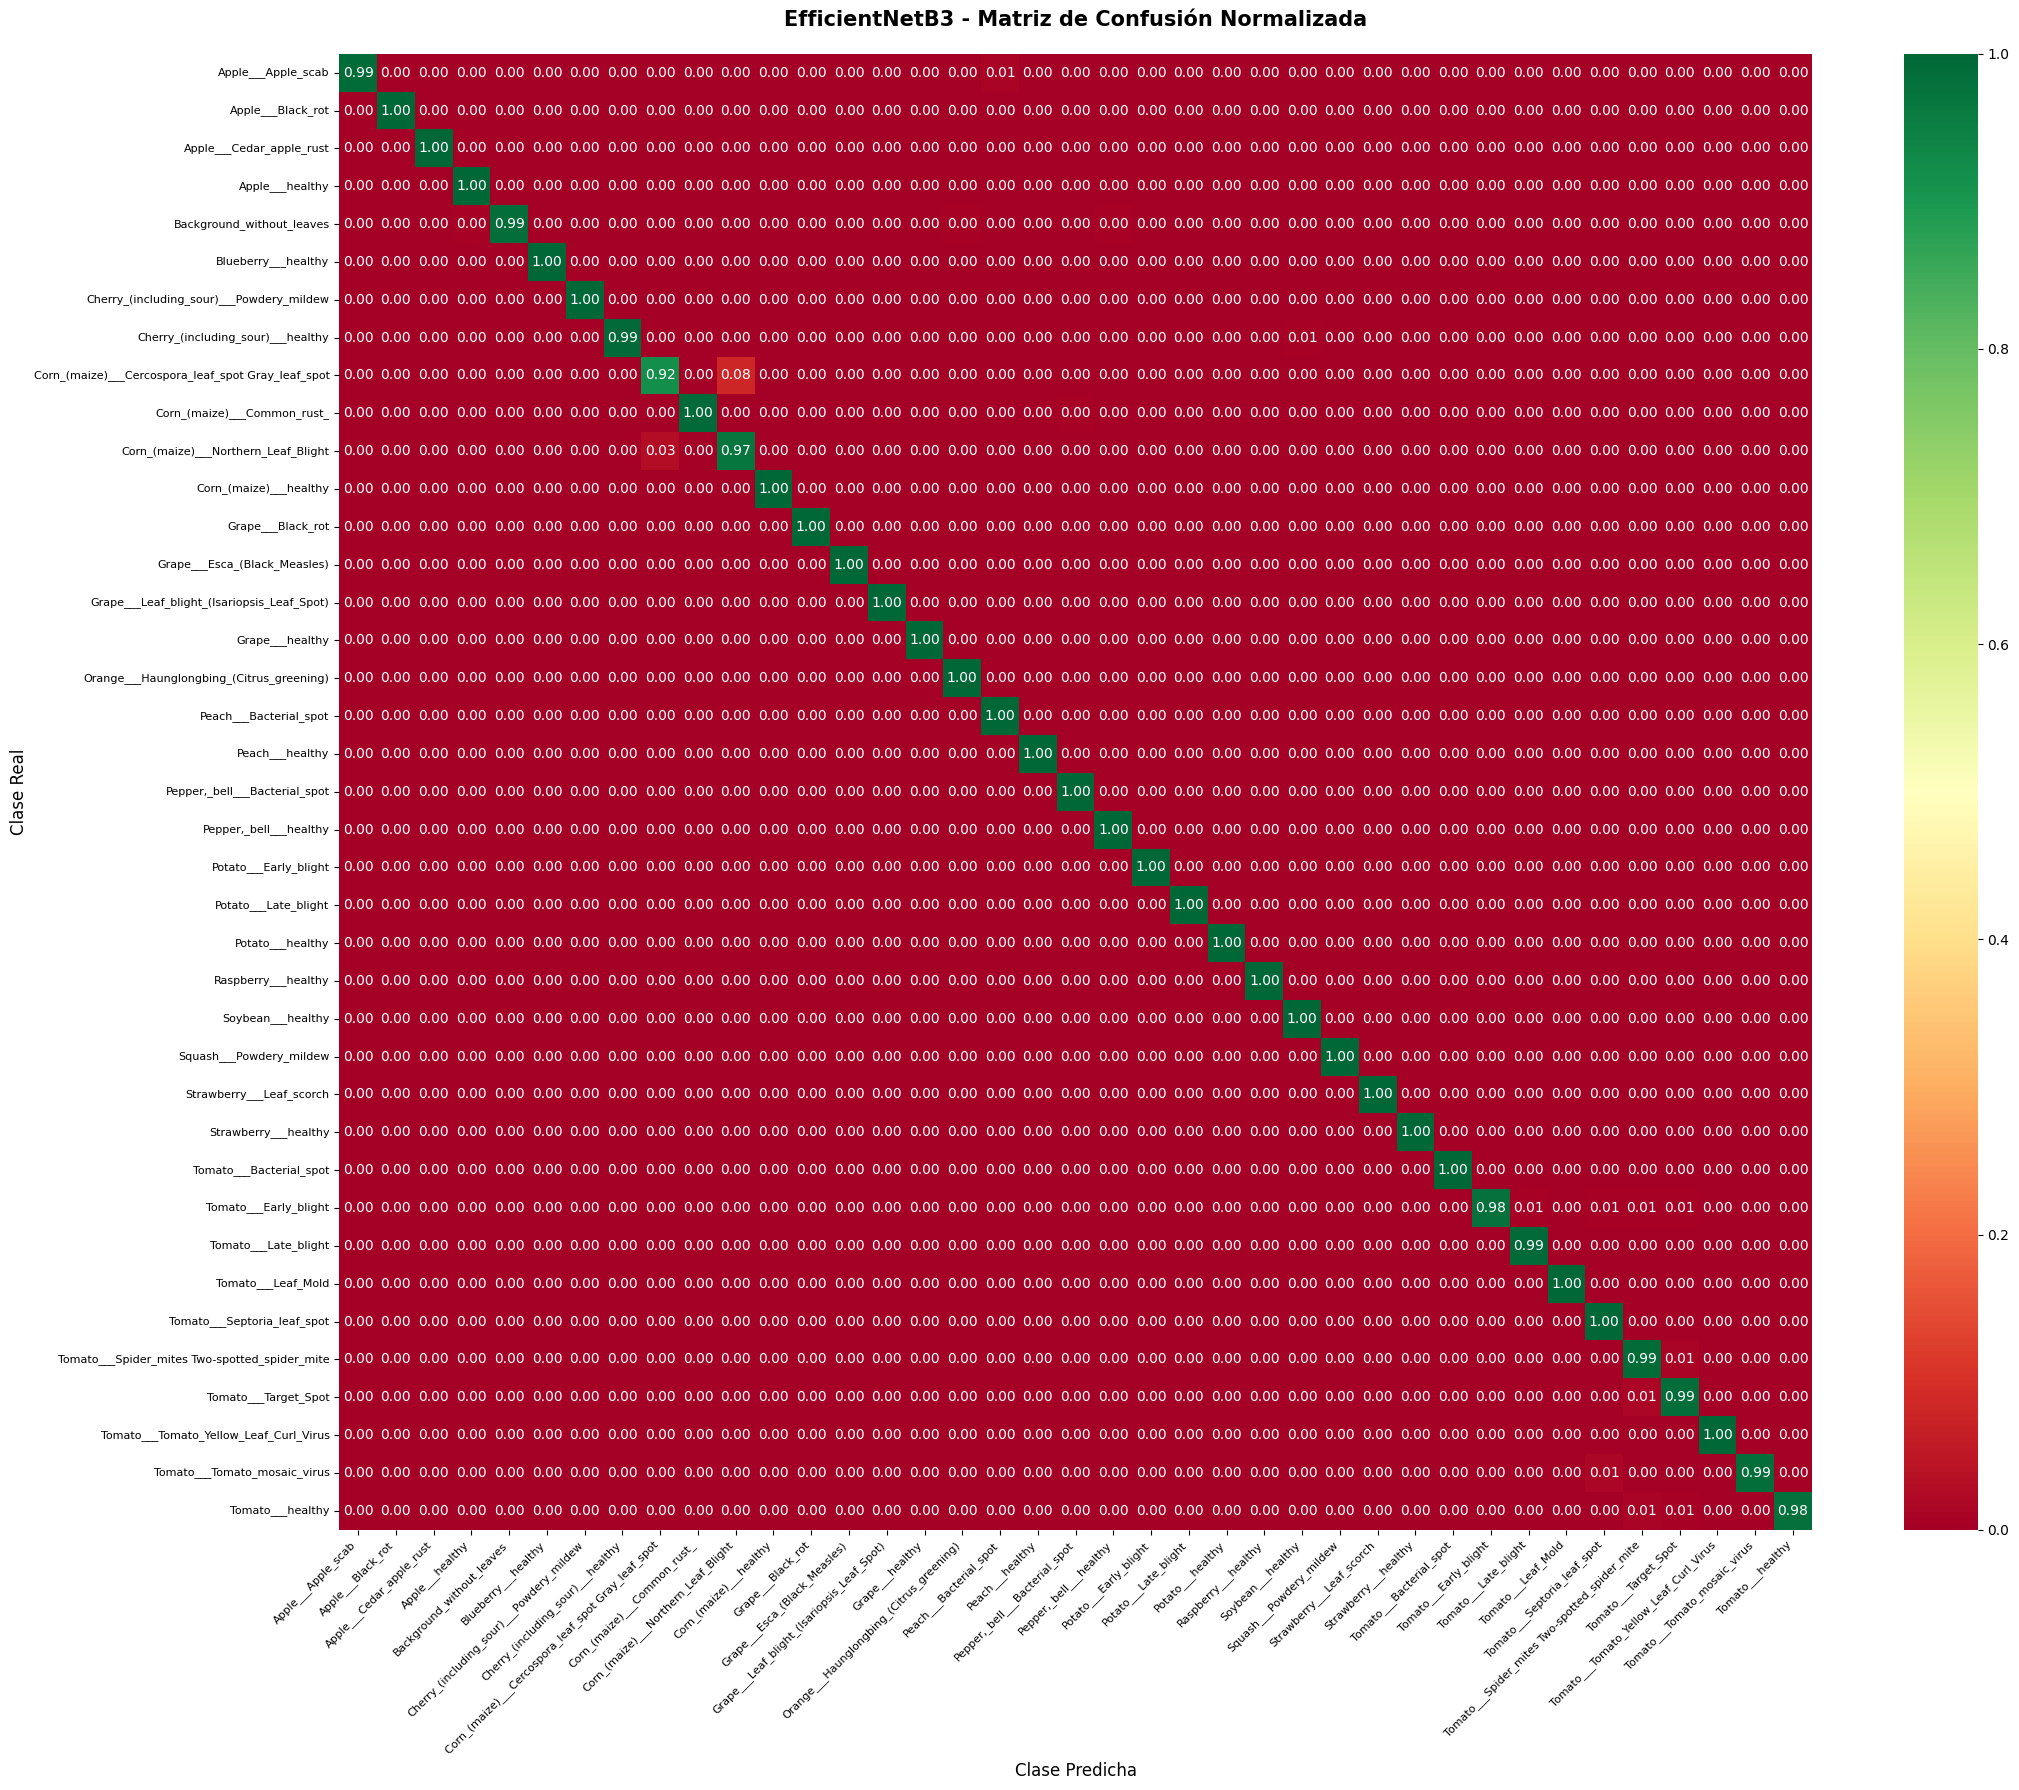

In [35]:
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(22, 18))
sns.heatmap(
    cm_norm, annot=True, fmt='.2f', cmap='RdYlGn',
    xticklabels=class_names, yticklabels=class_names,
    vmin=0, vmax=1
)
plt.title('EfficientNetB3 - Matriz de Confusión Normalizada', fontsize=15, fontweight='bold', pad=20)
plt.ylabel('Clase Real', fontsize=12)
plt.xlabel('Clase Predicha', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('efficientnetb3_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Reporte de clasificación

In [37]:
report = classification_report(y_true, y_pred, target_names=class_names, zero_division=0)
print('='*80)
print('REPORTE DE CLASIFICACIÓN - EfficientNetB3')
print('='*80)
print(report)

with open('efficientnetb3_classification_report.txt', 'w') as f:
    f.write('REPORTE DE CLASIFICACIÓN - EfficientNetB3\n')
    f.write('='*80 + '\n')
    f.write(report)
print('Guardado: efficientnetb3_classification_report.txt')

REPORTE DE CLASIFICACIÓN - EfficientNetB3
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       1.00      0.99      1.00       126
                                 Apple___Black_rot       1.00      1.00      1.00       124
                          Apple___Cedar_apple_rust       1.00      1.00      1.00        55
                                   Apple___healthy       1.00      1.00      1.00       329
                         Background_without_leaves       1.00      0.99      0.99       228
                               Blueberry___healthy       1.00      1.00      1.00       300
          Cherry_(including_sour)___Powdery_mildew       1.00      1.00      1.00       210
                 Cherry_(including_sour)___healthy       1.00      0.99      1.00       170
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.94      0.92      0.93       102
                       Corn_(maize)__

## 14. Curvas ROC

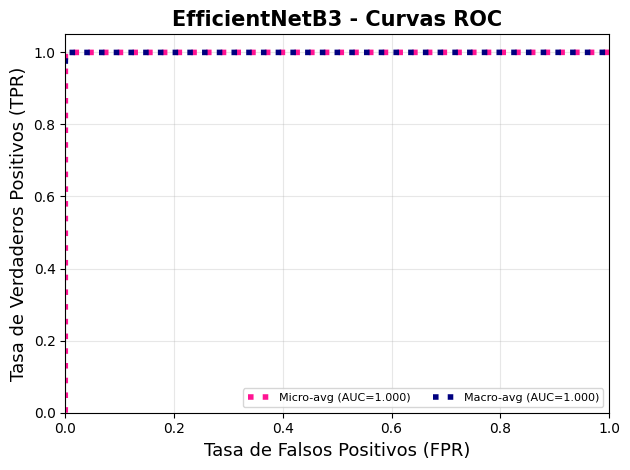

AUC Macro: 1.0000
AUC Micro: 1.0000


In [39]:
plt.plot(fpr['micro'], tpr['micro'], color='deeppink', linestyle=':', lw=4,
         label=f'Micro-avg (AUC={roc_auc["micro"]:.3f})')
plt.plot(fpr['macro'], tpr['macro'], color='navy', linestyle=':', lw=4,
         label=f'Macro-avg (AUC={roc_auc["macro"]:.3f})')
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=13)
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=13)
plt.title('EfficientNetB3 - Curvas ROC', fontsize=15, fontweight='bold')
plt.legend(loc='lower right', fontsize=8, ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('efficientnetb3_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'AUC Macro: {roc_auc["macro"]:.4f}')
print(f'AUC Micro: {roc_auc["micro"]:.4f}')

## 15. Guardar modelo y métricas

In [43]:
# Guardar modelo final
model.save('efficientnetb3_plantvillage_finetuned.h5')
print('Modelo guardado: efficientnetb3_plantvillage_finetuned.h5')

report_dict = classification_report(
    y_true, y_pred, target_names=class_names,
    output_dict=True, zero_division=0
)

metricas = {
    'arquitectura': 'EfficientNetB3',
    'pesos_base': 'ImageNet',
    'val_accuracy': float(val_acc),
    'val_loss': float(val_loss),
    'epocas_entrenadas': len(history.history['accuracy']),
    'macro_avg_precision': report_dict['macro avg']['precision'],
    'macro_avg_recall':    report_dict['macro avg']['recall'],
    'macro_avg_f1':        report_dict['macro avg']['f1-score'],
    'weighted_avg_f1':     report_dict['weighted avg']['f1-score'],
    'auc_macro':           float(roc_auc['macro']),
    'auc_micro':           float(roc_auc['micro']),
    'num_clases':          num_classes,
    'img_size':            IMG_SIZE,
    'parametros_totales':  int(model.count_params())
}

with open('efficientnetb3_metricas.json', 'w') as f:
    json.dump(metricas, f, indent=2)

print('\nMétricas guardadas: efficientnetb3_metricas.json')
print('\n=== RESUMEN FINAL ===')
for k, v in metricas.items():
    print(f'  {k}: {v}')

Modelo guardado: efficientnetb3_plantvillage_finetuned.h5

Métricas guardadas: efficientnetb3_metricas.json

=== RESUMEN FINAL ===
  arquitectura: EfficientNetB3
  pesos_base: ImageNet
  val_accuracy: 0.995847225189209
  val_loss: 0.016583556309342384
  epocas_entrenadas: 20
  macro_avg_precision: 0.9948890912849075
  macro_avg_recall: 0.9940114887644939
  macro_avg_f1: 0.9944368828571627
  weighted_avg_f1: 0.9958470842933687
  auc_macro: 0.9999802838280535
  auc_micro: 0.9999878366077259
  num_clases: 39
  img_size: 300
  parametros_totales: 11193174
